In [401]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, square, resample
import librosa
import soundfile as sf
import csv
from scipy.io.wavfile import write

Un sensor meteorologico remoto, diseñado para ser extremadamente eficiente en el uso de energia, transmite una actualización de estado cada hora. El sensor cuantifica el clima en solo cuatro estados posibles. Basado en el registro histórico anual de la region, se determino la siguiente distribucion de probabilidad para los estados:
- S1 (Despejado): P(S1) = 0,50 
- S2 (Nublado): P(S2) = 0,25 
- S3 (Lluvioso): P(S3) = 0,125 
- S4 (Tormenta severa): P(S4) = 0,125

Se solicita: 

a. Calcule analíticamente la entropía de Shannon H(S) de esta fuente de información en bits/símbolo. Muestre el desarrollo.

b. Escriba una funcion en Python llamada calcular entropia(probabilidades) que reciba una lista de probabilidades y retorne la entropia del sistema.


c. Utilice el codigo para verificar su resultado.

In [32]:
entropia = - (.5 * np.log2(.5) + .25*np.log2(.25) + .125 * np.log2(.125) + + .125 * np.log2(.125))
print(entropia)

1.75


In [33]:
def calcular_entropia(probabilidades):
    log = np.log2(probabilidades)
    suma = 0
    for i in range(len(probabilidades)):
        suma -= probabilidades[i] * log[i]
    
    return suma

In [34]:
print(calcular_entropia(np.array([.5,.25,.125,.125])))

1.75


Para diseñar un codigo de canal optimo (como el codigo Huffman), necesitamos conocer la entropia real de la fuente. Vamos a analizar la entropía de un texto escrito en español. Asumiremos un alfabeto de 28 caracteres (27 letras de la ’a’ a la ’z’, incluyendo la ’ñ’, más el caracter ’espacio’). Para este ejercicio, se le proporciona un diccionario en Python con las probabilidades estimadas de los 15 caracteres mas frecuentes en el idioma español. Para que el sistema este completo y las probabilidades sumen 1.0, se asume que las 13 letras restantes se reparten equitativamente la probabilidad residual.

In [35]:
frecuencias_espanol = { ' espacio ' : 0.145 , 'e'  : 0.115, 'a' : 0.105, 'o': 0.075, 's': 0.068, 'n' : 0.046 , 
                       'r'  : 0.045, 'i': 0.044, 'l': 0.040, 'd': 0.038, 't' : 0.035 , 'u' : 0.034, 
                       'c': 0.030, 'm': 0.025, 'p': 0.020 }


prob_restante = 1.0 - sum(frecuencias_espanol.values()) 
prob_letra_rara = prob_restante / 13.0


probabilidades = list(frecuencias_espanol.values()) + [prob_letra_rara] * 13

entropia_dicc = calcular_entropia(probabilidades)
entropia_max = calcular_entropia([-(1/28) * np.log2(1/28)] * 28)
redundancia = (1 - (entropia_dicc/entropia_max)) * 100

print(f'Entroía del diccionario: {entropia_dicc}')
print(f'Entropia maxima: {entropia_max}')
print(f'Porcentaje de redundancia: {redundancia}%')

Entroía del diccionario: 4.23957978620554
Entropia maxima: 12.220832722113029
Porcentaje de redundancia: 65.30858508083318%


En los sistemas de compresion reales (como los archivos .zip), el algoritmo primero debe ”leer” el archivo para aprender que simbolos se usan mas y calcular sus probabilidades empiricas.
Dado el siguiente mensaje de texto: “el veloz murcielago hindu comia feliz cardillo y kiwi” 
Se solicita que escriba un script en Python que realice las siguientes tareas de forma automatizada: 

a. Cuente la cantidad total de caracteres en el mensaje (incluyendo los espacios). 

b. Calcule la frecuencia absoluta (cuantas veces aparece) de cada caracter unico. 

c. Estime la probabilidad de aparicion de cada caracter. 

d. Calcule la Entropia de Shannon del mensaje en bits/caracter. 

Nota para el alumno: Asuma que el texto ya esta en minusculas y sin tildes para simplificar el analisis.

In [36]:
def extraer_recuento(texto):
    diccionario = {}
    
    for letra in texto:
        if letra in diccionario:
            diccionario[letra] += 1
        else:
            diccionario[letra] = 1
    
    return diccionario

def mostrar_dicc(dicc):
    dicc_frecuencias = {letra: cantidad / np.sum(list(dicc.values())) for letra, cantidad in dicc.items()}
    for k in dicc.keys():
        print(f"{k}: {dicc.get(k)} - {dicc_frecuencias.get(k):.2f}")


In [37]:
texto = 'el veloz murcielago hindu comia feliz cardillo y kiwi'
dicc = extraer_recuento(texto)
cantidad_caracteres = len(texto)

print(f"Cantidad de caracteres: {cantidad_caracteres}")
print(f"Frecuencia absoluta - relativa por carácter:")
mostrar_dicc(dicc)

dicc_frecuencias = {letra: cantidad / cantidad_caracteres for letra, cantidad in dicc.items()}

print("Entropía de Shannon [bits/carácter]: ",calcular_entropia(list(dicc_frecuencias.values())))

Cantidad de caracteres: 53
Frecuencia absoluta - relativa por carácter:
e: 4 - 0.08
l: 6 - 0.11
 : 8 - 0.15
v: 1 - 0.02
o: 4 - 0.08
z: 2 - 0.04
m: 2 - 0.04
u: 2 - 0.04
r: 2 - 0.04
c: 3 - 0.06
i: 7 - 0.13
a: 3 - 0.06
g: 1 - 0.02
h: 1 - 0.02
n: 1 - 0.02
d: 2 - 0.04
f: 1 - 0.02
y: 1 - 0.02
k: 1 - 0.02
w: 1 - 0.02
Entropía de Shannon [bits/carácter]:  3.94167452129797


## Ejercicio 4

In [38]:
w0 = 10000
w1 = 14000
Ptx = 5 # [Watts]
atenuacion = 21 # [dB]
N0 = 1.25e-6 # [Watts/Hz]

B = w1 - w0
S = Ptx/(np.pow(10,atenuacion/10)) # Despejamos dB
N = N0 * B # Potencia del ruido total
C = B * np.log2(1 + S/N) # Capacidad máxima teórica en bps
print(f"B: {B}")
print(f"S: {S}")
print(f"N: {N}")
print(f"C: {C}")


B: 4000
S: 0.03971641173621406
N: 0.005
C: 12643.217695652094


No es posible transmitir un video comprimido en baja resolución que requiere una tasa de datos de R = 12kbps, ya que el canal cuenta con 4kbps. Una forma de lograrlo sería aumentar la potencia de salida del ROV. Ahora bien, con una potencia de 12 Watts y un B de 30000 Hz (mejorando la capacidad frecuencial del transductor acústico) podríamos también. Otra alternativa es disminuir la distancia hasta la superficie, disminuyendo la atenuación hasta 21 dB.

## Ejercicio 5

In [39]:
def generar_senoidal(N, frecs, frecM, std=None):
    # N = n° segundos
    Tm = 1/frecM

    dom = np.arange(0, N, Tm)

    senoidal_final = np.zeros_like(dom)
    for f in range(len(frecs)):
        senoidal = np.sin(dom * 2 * np.pi * frecs[f])
        if std is not None:
            senoidal *= np.random.rand() * std

        senoidal_final += senoidal
    
    
    return dom, senoidal_final

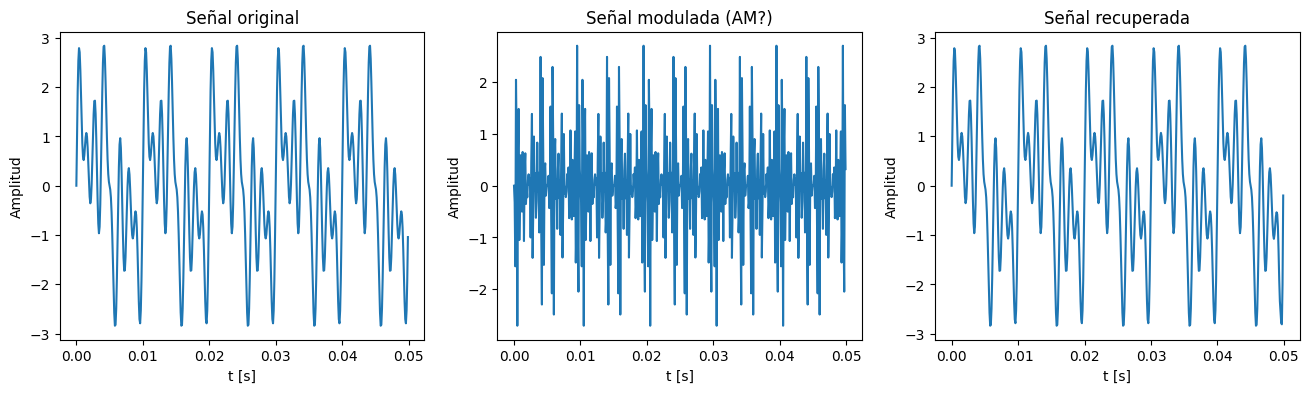

In [78]:
def am_sincrona(x, fs, fc):
    t = np.arange(len(x))/fs
    s = x * np.cos(2*np.pi*fc*t)
    s_dem = 2 * s * np.cos(2*np.pi*fc*t)
    
    # Aplicamos pasa bajos 😤🎉🦐
    wn = (fc * 0.8) / (fs / 2)  # frecuencia normalizada
    b, a = butter(5, wn, btype='low')
    s_dem = filtfilt(b, a, s_dem)

    return s, s_dem

fm = 10000
fc = 3000
# Escenario A
dom, x = generar_senoidal(0.05, [100, 300, 500, 800], fm)

A_s, A_s_dem = am_sincrona(x, fm, fc)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Señal original")
plt.plot(dom, x)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Señal modulada (AM?)")
plt.plot(dom, A_s)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Señal recuperada")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [79]:
audio, fs = librosa.load("Archivos para el TP-20260508/audio1.mp3", sr=None)

print(audio.shape)
print(fs)

(92160,)
44100


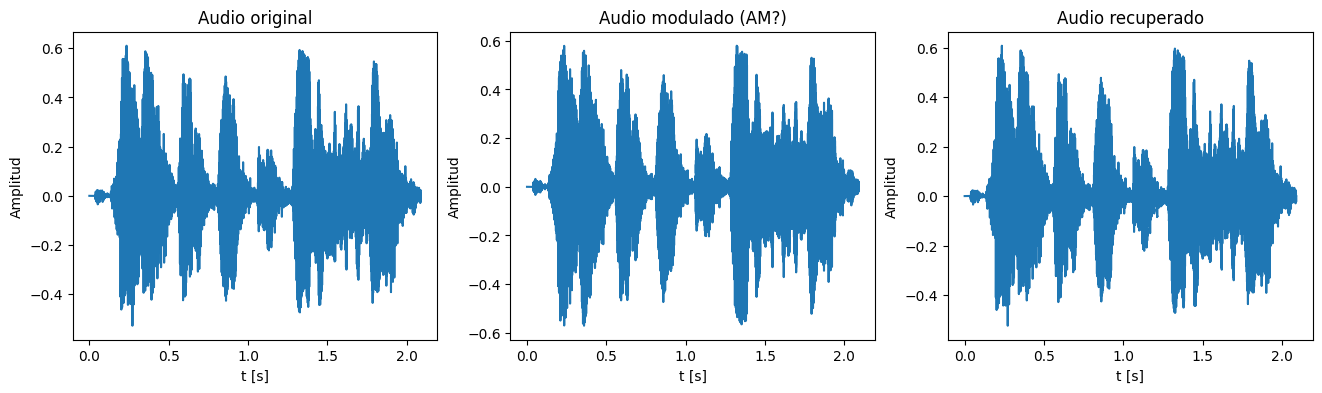

In [80]:
dom = np.arange(len(audio))/fs
# Escenario B
fc = 5000
# Escenario A
A_s, A_s_dem = am_sincrona(audio, fs, fc)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Audio original")
plt.plot(dom, audio)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Audio modulado (AM?)")
plt.plot(dom, A_s)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Audio recuperado")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [81]:
sf.write("Archivos para el TP-20260508/audio1_rec.wav", A_s_dem, fs)

In [82]:
# Escenario C

audio, fs = librosa.load("Archivos para el TP-20260508/audio2.mp3", sr=None)

print(audio.shape)
print(fs)

(588672,)
48000


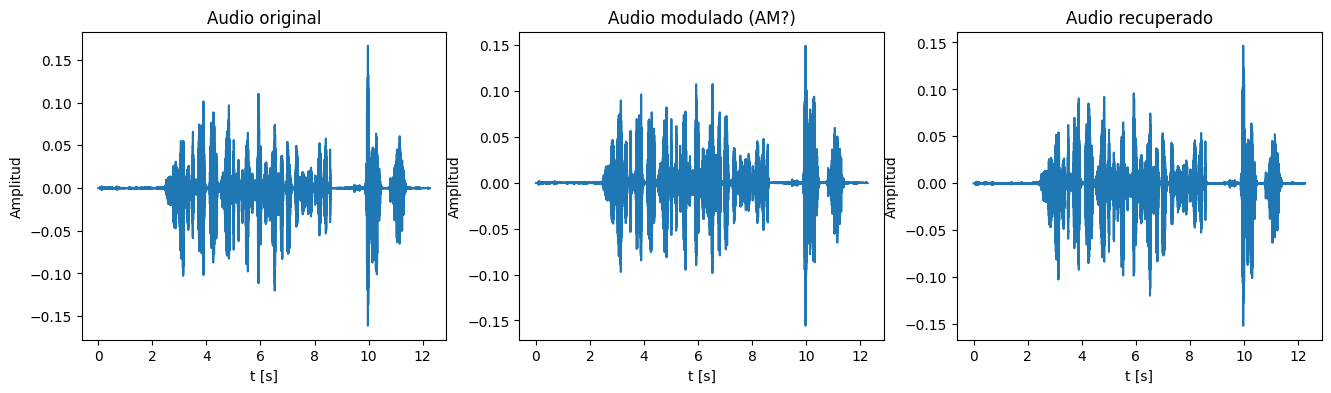

In [83]:
dom = np.arange(len(audio))/fs
# Escenario B
fc = 10000
# Escenario A
A_s, A_s_dem = am_sincrona(audio, fs, fc)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Audio original")
plt.plot(dom, audio)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Audio modulado (AM?)")
plt.plot(dom, A_s)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Audio recuperado")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [84]:
sf.write("Archivos para el TP-20260508/audio2_rec.wav", A_s_dem, fs)

## Ejercicio 6

In [216]:
def am_asincrona(x, fs, fc, A):
    t = np.arange(len(x))/fs
    s = (A + x) * np.cos(2*np.pi*fc*t)
    # Demodulación
    s_dem = np.maximum(s, 0) 
    
    # Aplicamos pasa bajos 😤🎉🦐
    wn = fc/3
    wn /= fs/2
    b, a = butter(5, wn, btype='low')
    s_dem = filtfilt(b, a, s_dem)

    s_dem -= np.mean(s_dem)
    s_dem /= np.max(np.abs(s_dem[100:-100]))

    return s, s_dem

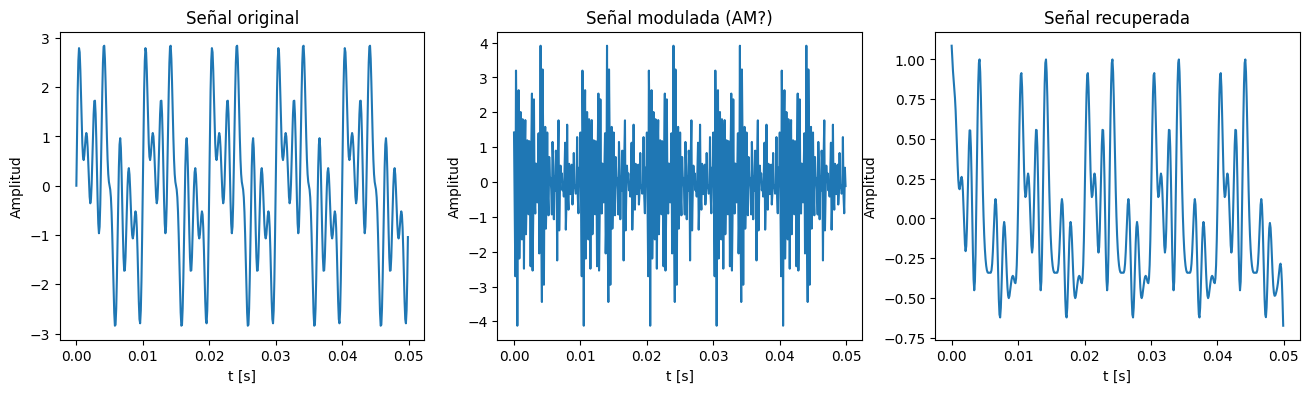

In [218]:
fm = 10000
fc = 3000
# Escenario A
dom, x = generar_senoidal(0.05, [100, 300, 500, 800], fm)
phi = 50
A = 0.5 * np.max(np.abs(x))

A_s, A_s_dem = am_asincrona(x, fm, fc, A)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Señal original")
plt.plot(dom, x)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Señal modulada (AM?)")
plt.plot(dom, A_s)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Señal recuperada")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [258]:
audio, fs = librosa.load("Archivos para el TP-20260508/audio1.mp3", sr=None)

print(audio.shape)
print(fs)

(92160,)
44100


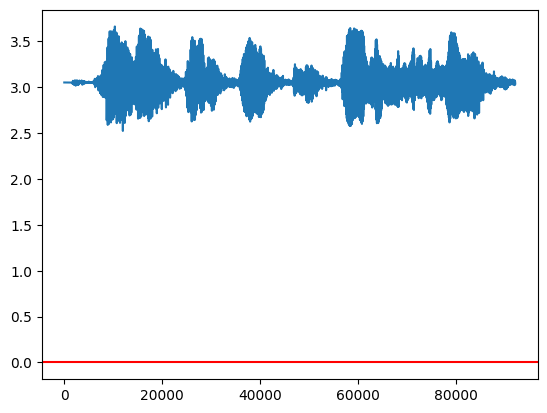

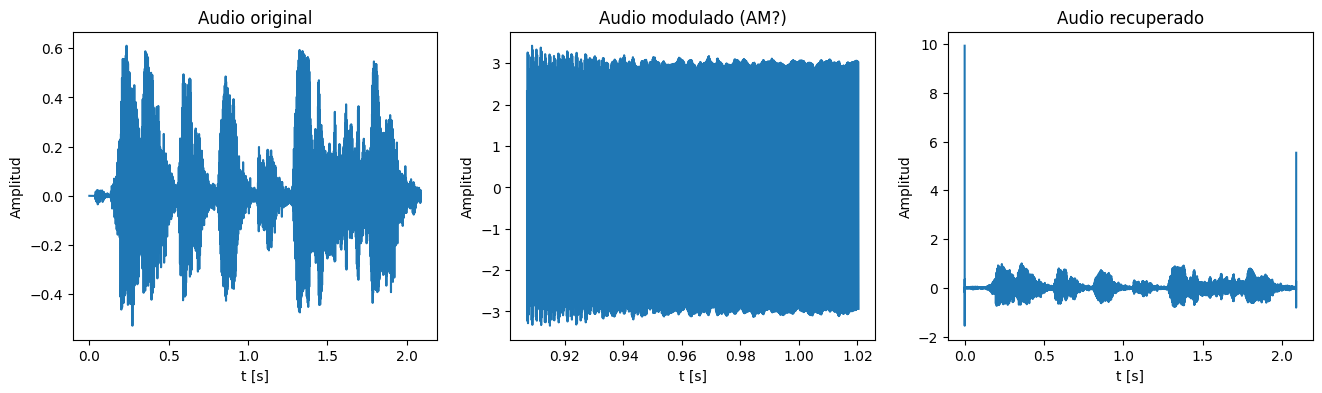

In [261]:
dom = np.arange(len(audio))/fs
# Escenario B
fc = 4000
# Escenario A
A = 5 * np.max(np.abs(audio))
A_s, A_s_dem = am_asincrona(audio, fs, fc, A)

env = A + audio

plt.plot(env)
plt.axhline(0, color='r')

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Audio original")
plt.plot(dom, audio)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Audio modulado (AM?)")
plt.plot(dom[40000:45000], A_s[40000:45000])
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Audio recuperado")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [254]:
sf.write("Archivos para el TP-20260508/audio1_asinc_rec.wav", A_s_dem, fs)

In [255]:
# Escenario C

audio, fs = librosa.load("Archivos para el TP-20260508/audio2.mp3", sr=None)

print(audio.shape)
print(fs)

(588672,)
48000


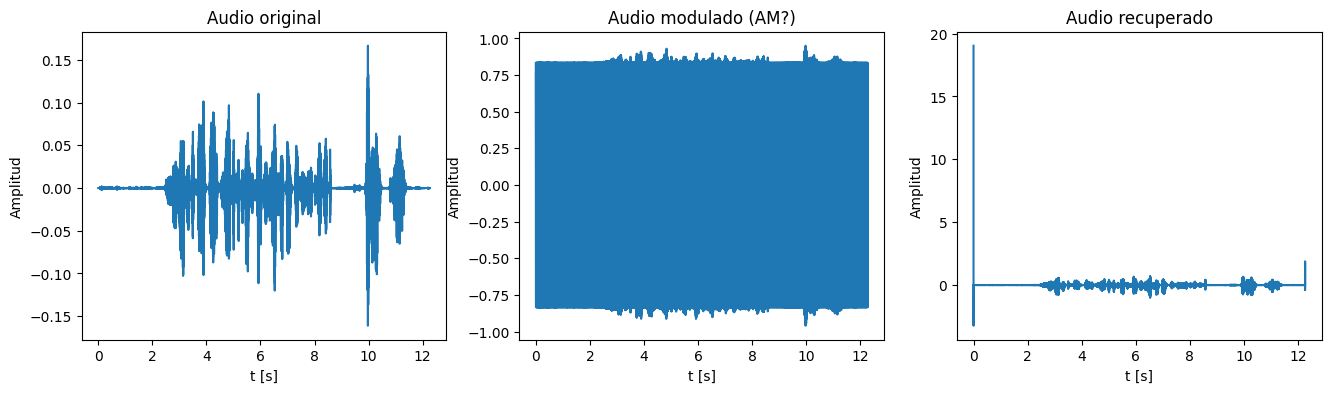

In [256]:
dom = np.arange(len(audio))/fs

fc = 9000
# Escenario C
A = 5 * np.max(np.abs(audio))
A_s, A_s_dem = am_asincrona(audio, fs, fc, A)

plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
plt.title("Audio original")
plt.plot(dom, audio)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,2)
plt.title("Audio modulado (AM?)")
plt.plot(dom, A_s)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(1,3,3)
plt.title("Audio recuperado")
plt.plot(dom, A_s_dem)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.show()

In [257]:
sf.write("Archivos para el TP-20260508/audio2_asinc_rec.wav", A_s_dem, fs)

Cuando hacemos la demodulación, la realizamos sobre A + x. El término mu = max(|x|)/A. Si A es mayor o igual al máximo valor que toma x, mu es menor a 1, y el término nunca pasa por el cero, pudiendo el detector de envolvente recuperar directamente la señal original. Por el contrario, si es mayor a 1, el término cruza varias veces al cero, y varios términos que se vuelven negativos pasan a 0 o a su valor absoluto. Esto causa que la señal empiece a distorsionarse. 

## Ejercicio 7

In [307]:
def modulacion_fm(x, fs, fc, kf):
    t = np.arange(len(x))/fs
    
    theta_0 = 2*np.pi*fc*t
    theta = theta_0 + 2 * np.pi * kf * np.cumsum(x) * 1/fs

    fm_smod = np.sin(theta_0)
    fm_modulada = np.sin(theta)
    
    P_smod = np.sum(np.pow(fm_smod, 2)) / len(fm_smod)
    P_mod = np.sum(np.pow(fm_modulada, 2)) / len(fm_modulada)
    print(f"Potencia portadora sin modular: {P_smod}")
    print(f"Potencia señal FM: {P_mod}")
    return fm_modulada

Potencia portadora sin modular: 0.4997531890507358
Potencia señal FM: 0.5019173110180644
Potencia portadora sin modular: 0.4997531890507358
Potencia señal FM: 0.501327641814643


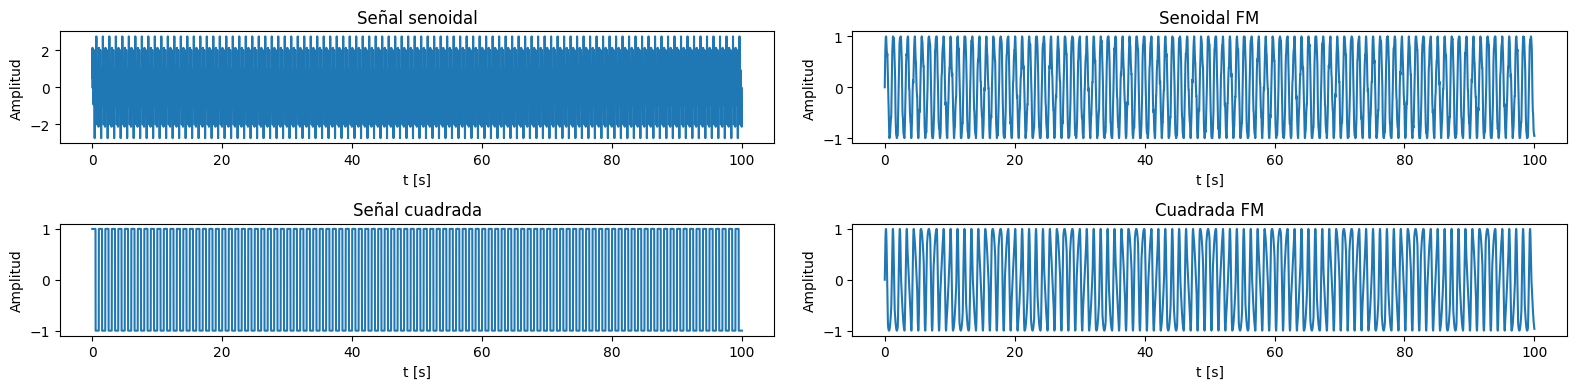

In [311]:
fm = 2000
fc = 20
kf = 10 # Hz/V
# Escenario A
dom, x = generar_senoidal(100, [2, 5, 10], fm)
fm_modulada = modulacion_fm(x, fs, fc, kf)

x_sq = square(2*np.pi*1*dom)
fm_modulada_sq = modulacion_fm(x_sq, fs, fc, kf)

plt.figure(figsize=(16,4))
plt.subplot(2,2,1)
plt.title("Señal senoidal")
plt.plot(dom, x)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,2)
plt.title("Senoidal FM")
plt.plot(dom, fm_modulada)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,3)
plt.title("Señal cuadrada")
plt.plot(dom, x_sq)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")

plt.subplot(2,2,4)
plt.title("Cuadrada FM")
plt.plot(dom, fm_modulada_sq)
plt.xlabel("t [s]")
plt.ylabel("Amplitud")
plt.tight_layout()
plt.show()

La potencia media entre ambas señales moduladoras se mantiene constante en 0,5. Esto se explica porque la portadora mantiene siempre una magnitud constante igual a 1, así que no hay motivos más allá de fallos numéricos que puedan ocasionar un cambio en la misma. 

## Ejercicio 8

In [404]:
def cargar_dataset(nombre_archivo):
    dataset = []
    with open(nombre_archivo, newline='') as csvfile:
      reader = csv.reader(csvfile)
      for row in reader:
        dataset.append(row[0])
    dataset = np.array(dataset)
    dataset = dataset[:].astype(float)
    return dataset

def am_sincrona(x, fs, fc):
    t = np.arange(len(x))/fs
    s_am = x * np.cos(2*np.pi*fc*t)
    return s_am

def dam_sincrona(x, fs, fc):
    t = np.arange(len(x))/fs
    s_dem = 2 * x * np.cos(2*np.pi*fc*t)
    
    # Aplicamos pasa bajos 😤🎉🦐
    wn = (fc * 0.8) / (fs / 2)  # frecuencia normalizada
    b, a = butter(5, wn, btype='low')
    s_dem = filtfilt(b, a, s_dem)
    
    return s_dem


def pasa_banda(x, fs, f_inf, f_sup, orden=5):
    wn = [f_inf/(fs/2), f_sup/(fs/2)]
    b, a = butter(orden, wn, btype='bandpass')
    return filtfilt(b, a, x)



In [405]:
VOZ = cargar_dataset("Archivos para el TP-20260508/voz.txt")
N_VOZ = len(VOZ)
print(N_VOZ/8000)
frecVOZ = 8000

ECG = cargar_dataset("Archivos para el TP-20260508/ecg.txt")
N_ECG = len(ECG)
print(N_ECG/250)
frecECG = 250

PA = cargar_dataset("Archivos para el TP-20260508/pa.txt")
N_PA = len(PA)
print(N_PA/100)
frecPA = 100


8.0
8.0
8.0


In [406]:
def pad_zeros(x, N):
    y = np.zeros(N)
    y[:len(x)] = x
    return y

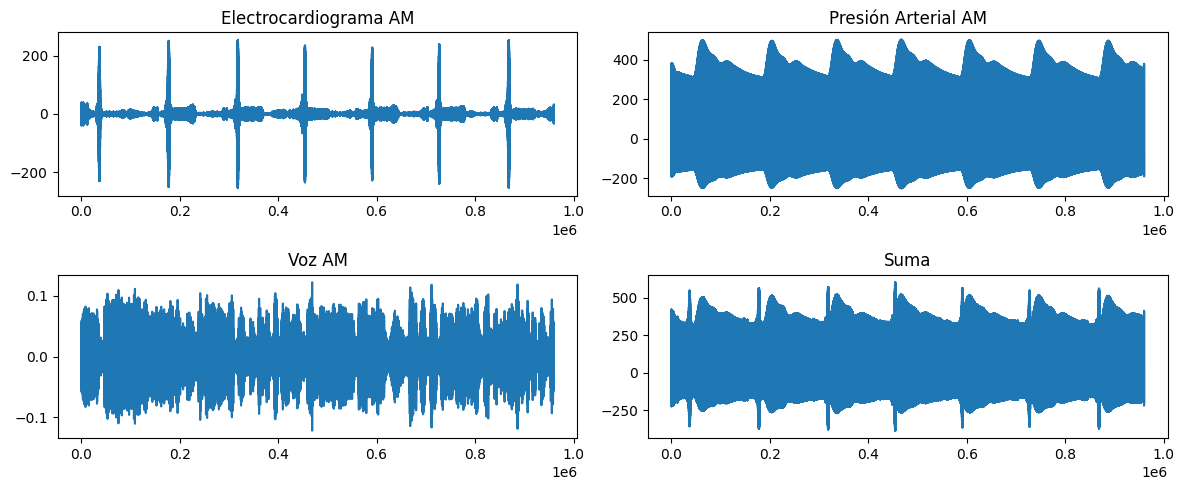

In [407]:
FCs = [30000, 40000, 50000]
frecDEM = 120000
N = frecDEM * 8

N_PA_new = int(len(PA) * frecDEM / frecPA)
PA_up = resample(PA, N)

N_ECG_new = int(len(ECG) * frecDEM / frecECG)
ECG_up = resample(ECG, N)

N_VOZ_new = int(len(VOZ) * frecDEM / frecVOZ)
VOZ_up = resample(VOZ, N)

N = max(
    len(ECG_up),
    len(PA_up),
    len(VOZ_up)
)
PA_AM = am_sincrona(PA_up, frecDEM, FCs[1])
ECG_AM = am_sincrona(ECG_up, frecDEM, FCs[2])
VOZ_AM = am_sincrona(VOZ_up, frecDEM, FCs[0])


AM_sum = ECG_AM + PA_AM + VOZ_AM

plt.figure(figsize=(12,5))
plt.subplot(2,2,1)
plt.title("Electrocardiograma AM")
plt.plot(ECG_AM)

plt.subplot(2,2,2)
plt.title("Presión Arterial AM")
plt.plot(PA_AM)

plt.subplot(2,2,3)
plt.title("Voz AM")
plt.plot(VOZ_AM)

plt.subplot(2,2,4)
plt.title("Suma")
plt.plot(AM_sum)

plt.tight_layout()
plt.show()

In [408]:
ancho = 5000

rec_ECG_AM = pasa_banda(AM_sum, frecDEM, FCs[2] - ancho, FCs[2] + ancho, 5)
rec_PA_AM = pasa_banda(AM_sum, frecDEM, FCs[1] - ancho, FCs[1] + ancho, 5)
rec_VOZ_AM = pasa_banda(AM_sum, frecDEM, FCs[0] - ancho, FCs[0] + ancho, 5)

rec_ECG = dam_sincrona(rec_ECG_AM, frecDEM, FCs[2])
rec_PA = dam_sincrona(rec_PA_AM, frecDEM, FCs[1])
rec_VOZ = dam_sincrona(rec_VOZ_AM, frecDEM, FCs[0])



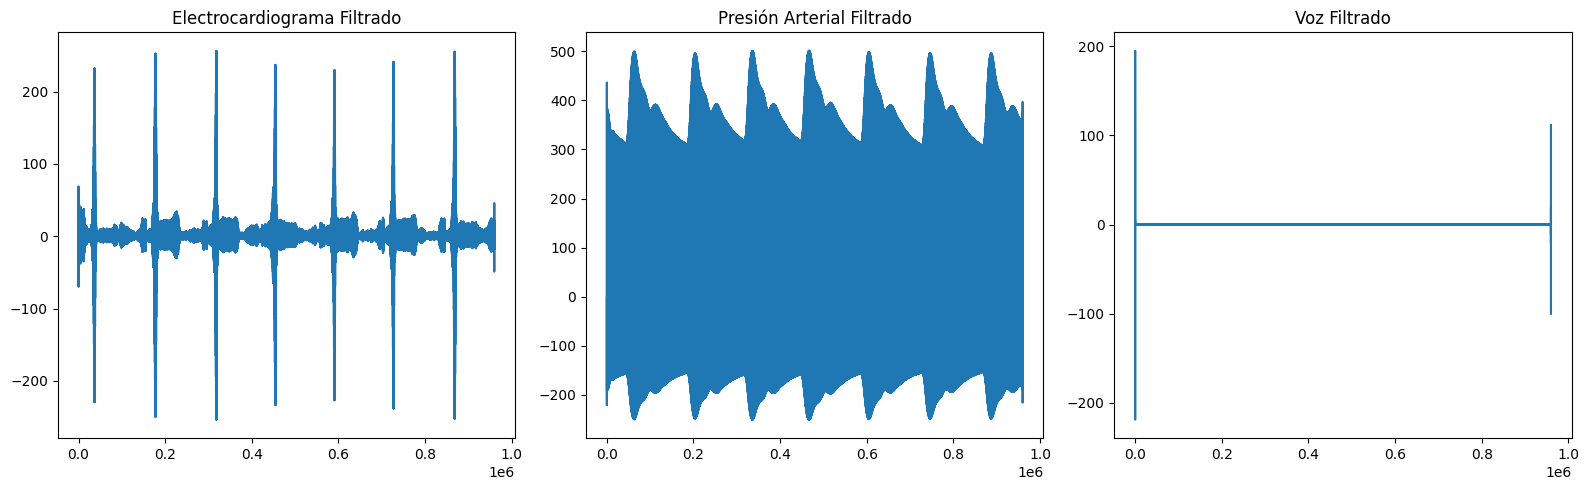

In [409]:
plt.figure(figsize=(16,5))
plt.subplot(1,3,1)
plt.title("Electrocardiograma Filtrado")
plt.plot(rec_ECG_AM)

plt.subplot(1,3,2)
plt.title("Presión Arterial Filtrado")
plt.plot(rec_PA_AM)

plt.subplot(1,3,3)
plt.title("Voz Filtrado")
plt.plot(rec_VOZ_AM)

plt.tight_layout()
plt.show()

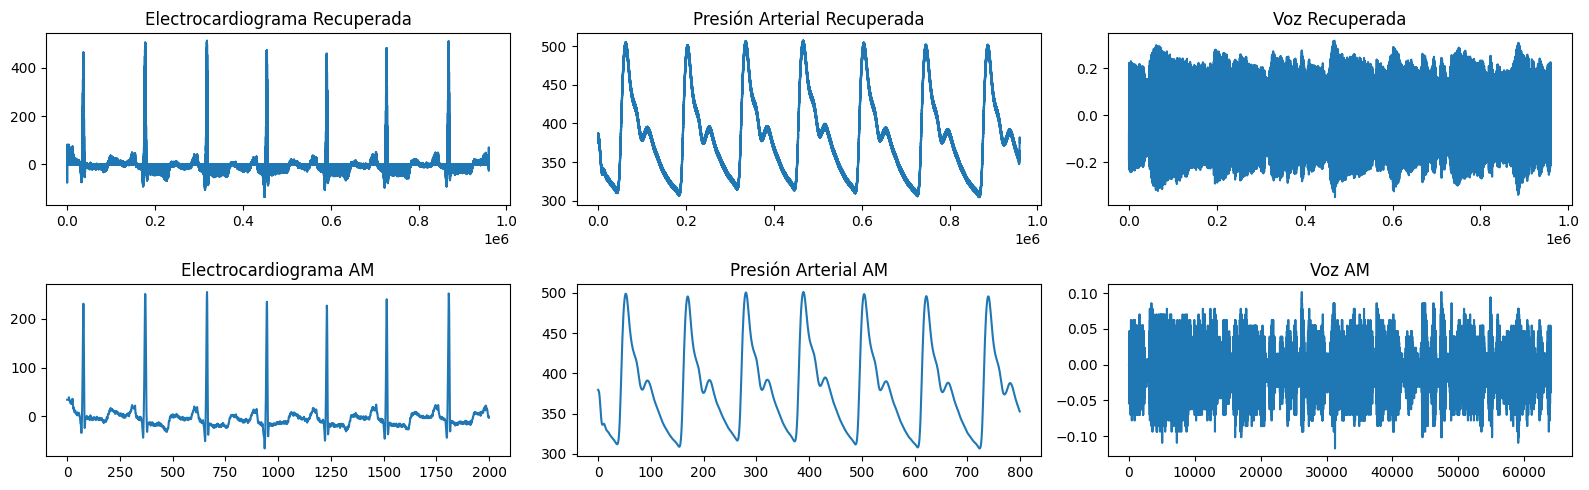

In [414]:
plt.figure(figsize=(16,5))
plt.subplot(2,3,1)
plt.title("Electrocardiograma Recuperada")
plt.plot(rec_ECG)

plt.subplot(2,3,2)
plt.title("Presión Arterial Recuperada")
plt.plot(rec_PA[100:-100])

plt.subplot(2,3,3)
plt.title("Voz Recuperada")
plt.plot(rec_VOZ[100:-100])

plt.subplot(2,3,4)
plt.title("Electrocardiograma AM")
plt.plot(ECG)

plt.subplot(2,3,5)
plt.title("Presión Arterial AM")
plt.plot(PA)

plt.subplot(2,3,6)
plt.title("Voz AM")
plt.plot(VOZ)

plt.tight_layout()
plt.show()

In [411]:
print(np.linalg.norm(ECG_up - rec_ECG))
print(np.linalg.norm(PA_up - rec_PA))
print(np.linalg.norm(VOZ_up - rec_VOZ))

23522.174821259752
3178.1118900312763
293.60288315836436


In [413]:
audio = VOZ

# Normalizar a [-1, 1]
audio = audio / np.max(np.abs(audio))

write(
    "voz_original.wav",
    frecVOZ,
    (audio * 32767).astype(np.int16)
)

audio = rec_VOZ

# Normalizar a [-1, 1]
audio = audio / np.max(np.abs(audio))

rec_VOZ_8k = resample(
    rec_VOZ,
    int(len(rec_VOZ) * 8000 / 120000)
)

sf.write(
    "voz_recuperada.wav",
    rec_VOZ_8k,
    8000
)